In [1]:
!pip install -q pycocotools

In [2]:
!pip install -q albumentations==1.0.3 opencv-python==4.5.5.64

In [3]:
import torch
from torch import nn
import torch.nn.functional as F
import warnings

warnings.simplefilter("ignore", category=UserWarning)

In [4]:
data_path = '/kaggle/input/arcade/arcade_challenge_datasets/dataset_phase_1/segmentation_dataset'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
import os
import cv2
import numpy as np
import albumentations as A

train_transform = A.Compose([
    A.Resize(width=512, height=512),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=1),
    A.ColorJitter(brightness=0.5, contrast=1, saturation=0.1, hue=0.5)
])

valid_transform = A.Compose([
    A.Resize(width=512, height=512)
])


def create_mask(img_id, coco):
    anns_ids = coco.getAnnIds(imgIds=img_id, iscrowd=None)
    anns = coco.loadAnns(anns_ids)
    mask = coco.annToMask(anns[0])
    
    for i in range(len(anns)):
        mask+=coco.annToMask(anns[i])
    
    mask = (mask>=1).astype(np.float32)
    
    return mask
    
def load_dataset(dir_path, coco, it = 5):
    img = []
    mask = []
    
    imgs_dict = coco.imgs
    
    for img_item in imgs_dict.values():
        img.append(os.path.join(dir_path,img_item['file_name']))
        mask.append(img_item['id'])
    
    return img, mask

In [6]:
from PIL import Image
from pycocotools.coco import COCO
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

class VCDDataset(Dataset):
    def __init__(self, dir_path, coco, transform=None):
        X,y = load_dataset(dir_path, coco)
        self.X = X
        self.y = y
        self.coco = coco
        self.transform = transform
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self,i):
        img = Image.open(self.X[i]).convert('L')
        img = np.array(img)

        mask = create_mask(self.y[i], self.coco)
        old_mask = mask

        if self.transform:
            sample = self.transform(image=img, mask=mask)
            img = sample['image']
            mask = sample['mask']
            mask = v2.ToTensor()(mask)
            img = v2.ToTensor()(img)
            
        return img, mask, old_mask

train_data_path = os.path.join(data_path,'seg_train/images')
valid_data_path = os.path.join(data_path,'seg_val/images')

coco_train = COCO(os.path.join(data_path,'seg_train/annotations/seg_train.json'))
coco_valid = COCO(os.path.join(data_path,'seg_val/annotations/seg_val.json'))

train_dataset = VCDDataset(train_data_path, coco_train, transform=train_transform)
valid_dataset = VCDDataset(valid_data_path, coco_valid, transform = train_transform)  

len(train_dataset), len(valid_dataset)

loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


(1000, 200)

In [7]:
train_dataloader = DataLoader(train_dataset,batch_size=8, shuffle=True)
valid_dataloader = DataLoader(valid_dataset,batch_size=8)

torch.Size([8, 1, 512, 512]) torch.Size([8, 1, 512, 512])


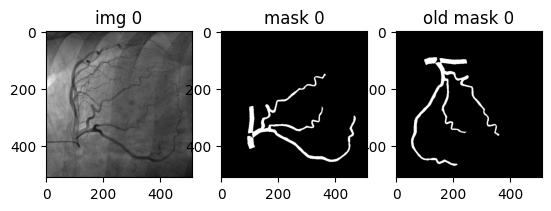

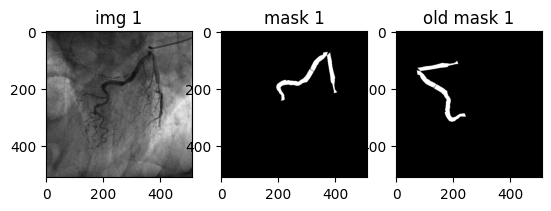

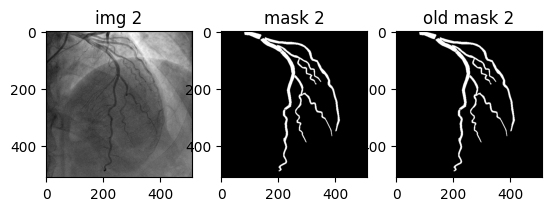

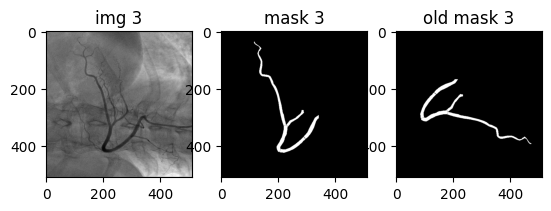

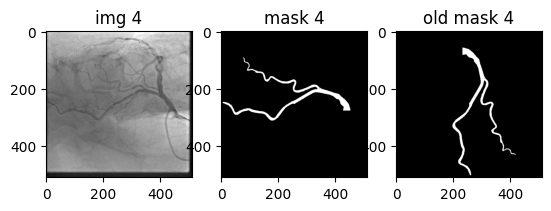

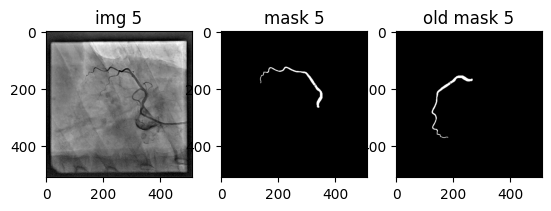

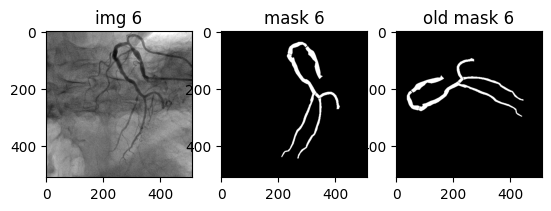

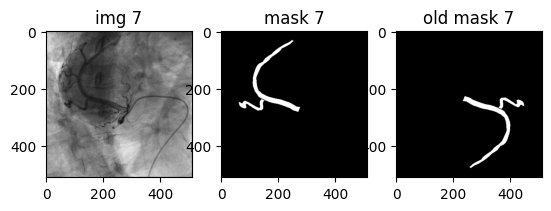

In [8]:
import matplotlib.pyplot as plt
import torchvision.transforms as t
from PIL import Image


for item in train_dataloader:
    img, mask, old_mask = item
    print(img.shape, mask.shape)
    for i in range(len(img)):
        fig, ax = plt.subplots(1, 3)
        
        orig_img = t.ToPILImage()(img[i])
        orig_mask  = t.ToPILImage()(mask[i])
        orig_old_mask = t.ToPILImage()(old_mask[i])

        orig_img.save(f'{i}.png')
        orig_mask.save(f'{i}_mask.png')
        
        ax[0].imshow(orig_img, cmap='gray')
        ax[0].set_title(f'img {i}')

        ax[1].imshow(orig_mask, cmap='gray')
        ax[1].set_title(f'mask {i}')

        ax[2].imshow(orig_old_mask, cmap='gray')
        ax[2].set_title(f'old mask {i}')
        plt.show()
    break

In [9]:
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c,out_c,(3,3),padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_c,out_c,(3,3),padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(inplace=True)
            )
    
    def forward(self,x):
        return self.conv(x)

class DownConv(nn.Module):
    def __init__(self,in_c, out_c):
        super().__init__()
        self.conv = DoubleConv(in_c,out_c)
        self.pool =  nn.MaxPool2d((2,2),stride=2)
    
    def forward(self,x):
        skip_conn = self.conv(x)
        return skip_conn, self.pool(skip_conn)

class UpConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.in_c = in_c
        self.out_c = out_c
        self.up = nn.ConvTranspose2d(in_c,out_c,(2,2),stride=2)
        self.conv = DoubleConv(out_c*2,out_c)
    
    def forward(self,x1,x2):
        x2 = self.up(x2)
        x = torch.cat([x1,x2],dim=1)
        return self.conv(x)

In [10]:
class Unet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DownConv(1,64)
        self.down2 = DownConv(64,128)
        self.down3 = DownConv(128,256)
        self.down4 = DownConv(256,512)

        self.bottle = DoubleConv(512,1024)

        self.up1 = UpConv(1024,512)
        self.up2 = UpConv(512,256)
        self.up3 = UpConv(256,128)
        self.up4 = UpConv(128,64)

        self.final = nn.Conv2d(64,1,(1,1))

    def forward(self,x):

        s1,x = self.down1(x)
        s2,x = self.down2(x)
        s3,x = self.down3(x)
        s4,x = self.down4(x)

        x = self.bottle(x)

        x = self.up1(s4,x)
        x = self.up2(s3,x)
        x = self.up3(s2,x)
        x = self.up4(s1,x)

        return nn.Sigmoid()(self.final(x))
        #return self.final(x)


In [11]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        bce = F.binary_cross_entropy(pred, target)

        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        dice = 1. - (2. * intersection + self.smooth) / (union + self.smooth)
        
        return 0.5*bce + 0.5*dice

In [12]:
import torchmetrics

iou_metric = torchmetrics.JaccardIndex(task='binary').to(device)
dice_metric = torchmetrics.Dice(zero_division=1).to(device)
precision_metric = torchmetrics.Precision(task='binary').to(device)
recall_metric = torchmetrics.Recall(task='binary').to(device)

In [14]:
from tqdm import tqdm

model = Unet()
model.to(device)
optim = torch.optim.AdamW(model.parameters(),lr=1e-4, weight_decay=1e-5)
criterion = DiceBCELoss().to(device)
#criterion = nn.BCELoss().to(device)
epochs = 60
min_loss = 10000
loss_values = []
vloss_values = []
metrics = {
    'iou': [],
    'dice': [],
    'precision': [],
    'recall': []
}

for epoch in tqdm(range(epochs)):
    print(f'epochs:{epoch}')
    running_loss = 0.0
    model.train(True)
    for i, item in enumerate(train_dataloader):
        img, mask, _ = item
        mask = mask.to(device)
        img = img.to(device)
        out = model(img)
        
        loss = criterion(out,mask)
        
        loss.backward()
        optim.step()
        optim.zero_grad()
        
        running_loss += loss.item()
    
    model.eval()
    running_vloss = 0.0
    
    with torch.no_grad():
        for i, item in enumerate(valid_dataloader):
            img, mask, _ = item
            img = img.to(device)
            mask = mask.to(device)
            
            out = model(img)
            
            loss = criterion(out,mask)
            running_vloss += loss.item()

            pred_mask = (out > 0.5).float()
            true_mask = mask.long()
            iou_metric.update(pred_mask, true_mask)
            dice_metric.update(pred_mask, true_mask)
            precision_metric.update(pred_mask, true_mask)
            recall_metric.update(pred_mask, true_mask)

    iou = iou_metric.compute()
    dice = dice_metric.compute()
    precision = precision_metric.compute()
    recall = recall_metric.compute()
    
    metrics['iou'].append(iou)
    metrics['dice'].append(dice)
    metrics['precision'].append(precision)
    metrics['recall'].append(recall)

    iou_metric.reset()
    dice_metric.reset()
    precision_metric.reset()
    recall_metric.reset()
    
    running_loss = running_loss/len(train_dataloader)
    running_vloss = running_vloss/len(valid_dataloader)
    
    loss_values.append(running_loss)
    vloss_values.append(running_vloss)
    print(f'train and valid loss after epoch: {running_loss:.4f}, {running_vloss:.4f}')
    print(f'IOU: {iou:.4f}, dice: {dice:.4f}, precision: {precision:.4f}, recall: {recall:.4f}')
    
    if min_loss > running_vloss:
        min_loss = running_vloss
        torch.save(model.state_dict(), 'model.pth')
        print('model saved')
    print('-----------------------------')

  0%|          | 0/60 [00:00<?, ?it/s]

epochs:0


  2%|▏         | 1/60 [02:15<2:13:05, 135.35s/it]

train and valid loss after epoch: 0.6849, 0.6408
IOU: 0.3288, dice: 0.4948, precision: 0.4592, recall: 0.5365
model saved
-----------------------------
epochs:1
train and valid loss after epoch: 0.6025, 0.5789
IOU: 0.3763, dice: 0.5469, precision: 0.4602, recall: 0.6737


  3%|▎         | 2/60 [04:30<2:10:58, 135.50s/it]

...

train and valid loss after epoch: 0.1304, 0.1556
IOU: 0.6146, dice: 0.7613, precision: 0.7527, recall: 0.7701
-----------------------------
epochs:58
train and valid loss after epoch: 0.1303, 0.1501
IOU: 0.6248, dice: 0.7691, precision: 0.7657, recall: 0.7726


 98%|█████████▊| 59/60 [2:13:12<02:15, 135.19s/it]

model saved
-----------------------------
epochs:59
train and valid loss after epoch: 0.1323, 0.1494
IOU: 0.6245, dice: 0.7689, precision: 0.7807, recall: 0.7574


100%|██████████| 60/60 [2:15:28<00:00, 135.47s/it]

model saved
-----------------------------


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


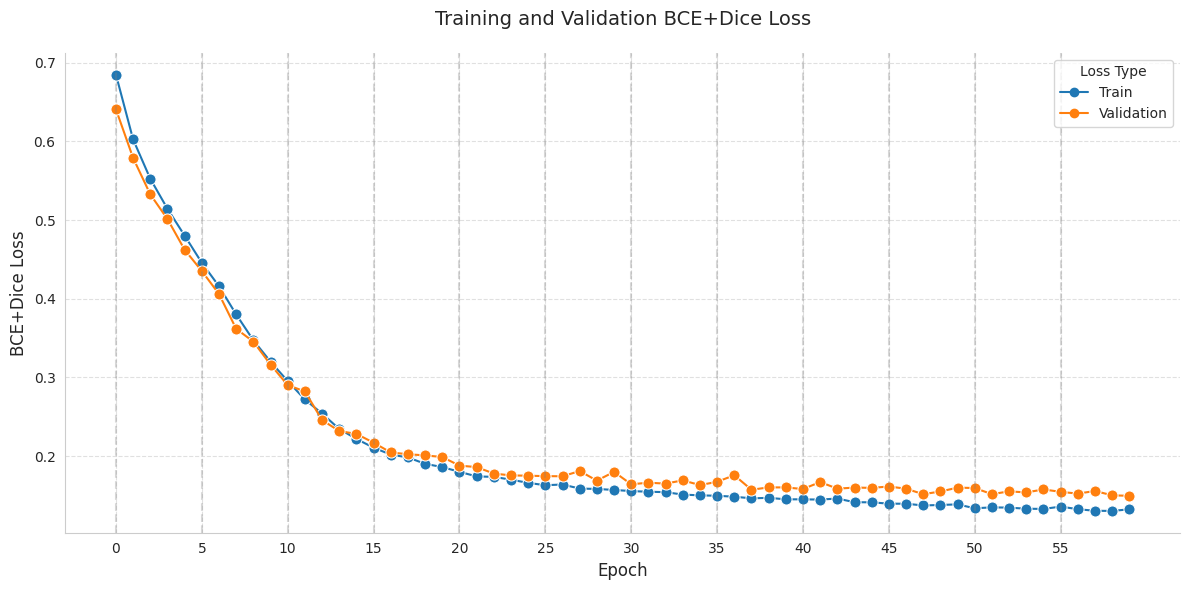

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

epochs = list(range(60))
data = pd.DataFrame({
    'Epoch': epochs*2,
    'Loss': loss_values + vloss_values,
    'Type': ['Train'] * len(epochs) + ['Validation'] * len(epochs)
})

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=data,
    x='Epoch',
    y='Loss',
    hue='Type',
    style='Type',
    dashes=False,
    markersize=8,
    markers={'Train': 'o', 'Validation': 'o'},
)

plt.title('Training and Validation BCE+Dice Loss', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE+Dice Loss', fontsize=12)
plt.xticks(epochs[::5])

for epoch in epochs[::5]:
    plt.axvline(x=epoch, color='gray', linestyle='--', alpha=0.3)

plt.legend(title='Loss Type', loc='upper right')

ax.grid(True, linestyle='--', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.savefig('loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
metrics.keys()

dict_keys(['iou', 'dice', 'precision', 'recall'])

In [21]:
metrics['iou'][0]

tensor(0.3288, device='cuda:0')

In [25]:
metrics_cpu = {key:[item.detach().cpu().item() for item in value] for key, value in metrics.items()}
metrics_cpu['iou'][0]

0.32877063751220703

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


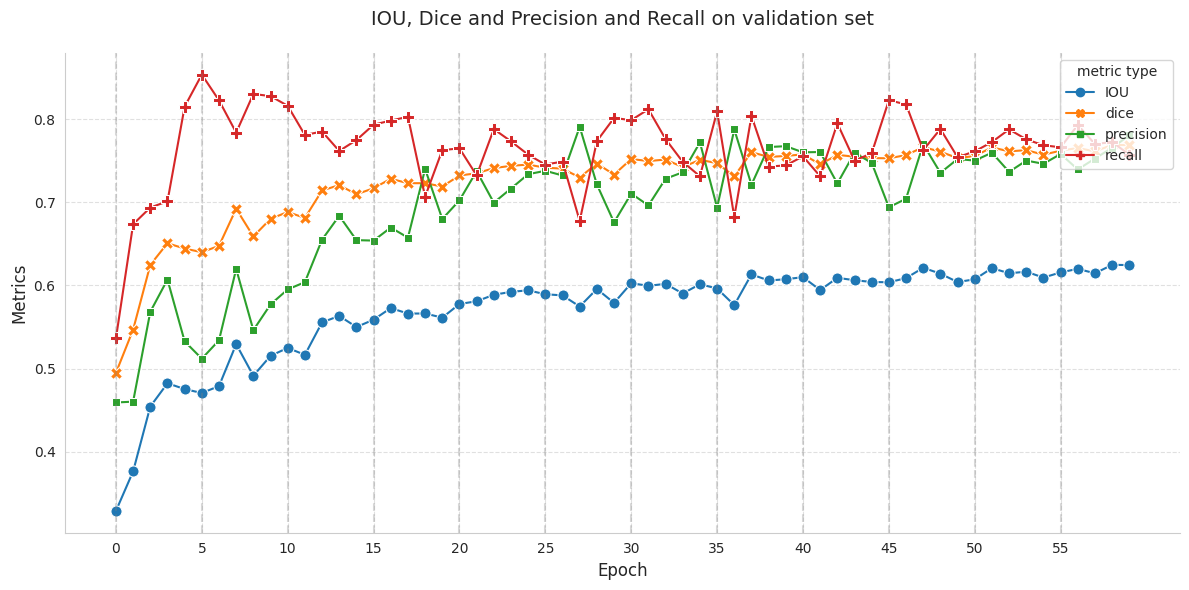

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

epochs = list(range(60))

data = pd.DataFrame({
    'Epoch': epochs*4,
    'Metrics': metrics_cpu['iou'] + metrics_cpu['dice'] + metrics_cpu['precision'] + metrics_cpu['recall'],
    'Type': ['IOU'] * len(epochs) + ['dice'] * len(epochs) + ['precision'] * len(epochs) + ['recall'] * len(epochs)
})

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=data,
    x='Epoch',
    y='Metrics',
    hue='Type',
    style='Type',
    dashes=False,
    markersize=8,
    markers=True,
    #markers={'IOU': 'o', 'mAP@50': 'o', 'mAP@75': 'o'},
)

plt.title('IOU, Dice and Precision and Recall on validation set', fontsize=14, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.xticks(epochs[::5])

for epoch in epochs[::5]:
    plt.axvline(x=epoch, color='gray', linestyle='--', alpha=0.3)

plt.legend(title='metric type', loc='upper right')

ax.grid(True, linestyle='--', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.savefig('metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
model = Unet()
model.load_state_dict(torch.load('/kaggle/input/unet-arcade-bce/pytorch/default/1/model.pth'))
model.to(device)
model.eval()

/tmp/ipykernel_30/2830717156.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/kaggle/input/unet-arcade-bce/pytorch/default/1/model.pth'

Unet(
  (down1): DownConv(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01, inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.01, inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownConv(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01, inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), s